# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps 
import numpy as np 
import math

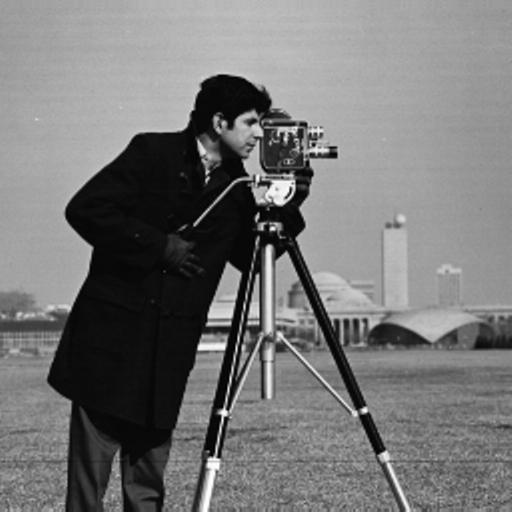

In [2]:
# ── Load image ────────────────────────────────────
img = Image.open("cameraman.jpg") 
img 

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size

# scaling factors
new_width = width * 2
new_height = height * 2

# high-quality
scaled_img = img.resize((new_width, new_height), Image.LANCZOS)
scaled_img.show()

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_img = img.resize((width * 2, height * 2), Image.LANCZOS)
scaled_img.show()

In [5]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg") 
print(img.size) 
print(scaled_img.size)

(512, 512)
(1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
cx = 2 
cy = 1 
non_uniform_scaled = img.resize((width * cx, height * cy), Image.Resampling.LANCZOS) 
non_uniform_scaled.save("task1_1_non_uniform_scaled.jpg")

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [7]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(120, expand=True) 
rotated_img.save("task1_2_rotated.jpg") 
print(rotated_img.size)

(700, 700)


### 3. Shear

In [8]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size 

In [9]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5 
shy = 0
new_width = int(width + abs(shx) * height) 
new_height = int(height + abs(shy) * width)

In [10]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform( 
    (new_width, new_height), 
    Image.Transform.AFFINE, 
    (1, shx, 0,
    shy, 1, 0), 
    resample=Image.Resampling.BICUBIC 
)

In [11]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

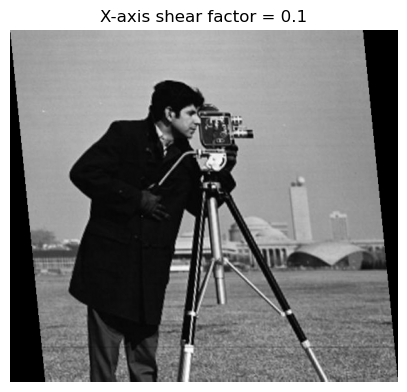

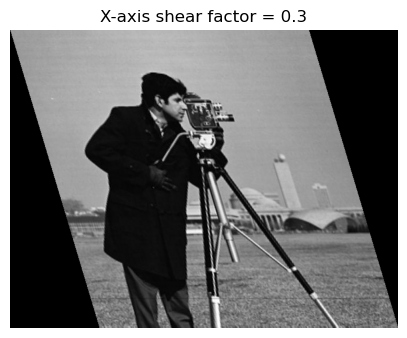

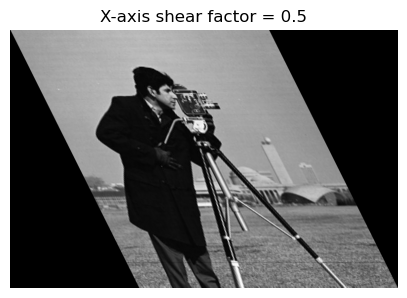

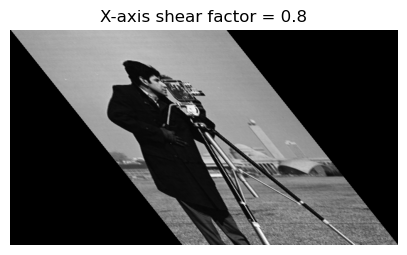

In [13]:
factors = [0.1, 0.3, 0.5, 0.8]

for shx in factors:
    # canvas multiplier:
    new_width = int(width * (1 + shx))
    new_height = height

    sheared = img.transform(
        (new_width, new_height),
        Image.Transform.AFFINE,
        (1, -shx, 0,
         0, 1, 0),
        resample=Image.Resampling.BICUBIC
    )

    sheared.save(f"task1_3_shear_x_{shx}.jpg")

    plt.figure(figsize=(5, 5))
    plt.imshow(sheared, cmap="gray")
    plt.title(f"X-axis shear factor = {shx}")
    plt.axis("off")
    plt.show()

— Switch from X-axis to Y-axis shear matrix (Update the canvas multiplier to match your new factor)

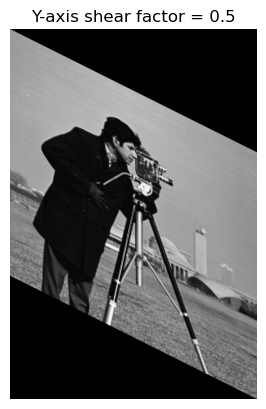

In [14]:
shy = 0.5

new_width = width
new_height = int(height * (1 + shy))

y_sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, 0, 0,
     -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

y_sheared_img.save("task1_3_y_sheared.jpg")

plt.imshow(y_sheared_img, cmap="gray")
plt.title("Y-axis shear factor = 0.5")
plt.axis("off")
plt.show()

— Try combining X and Y shear in one matrix

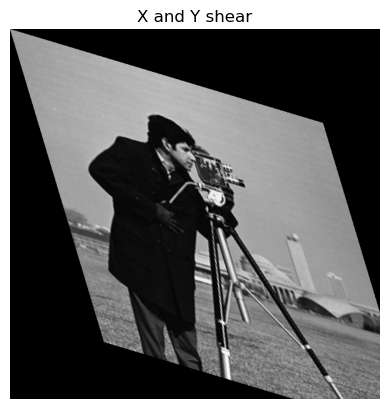

In [15]:
shx = 0.3
shy = 0.3

new_width = int(width * (1 + shx))
new_height = int(height * (1 + shy))

xy_sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0,
     -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

xy_sheared_img.save("task1_3_xy_sheared.jpg")

plt.imshow(xy_sheared_img, cmap="gray")
plt.title("X and Y shear")
plt.axis("off")
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [16]:
# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
arr = np.array(img) 
negative_arr = 255 - arr 
negative_img = Image.fromarray(negative_arr) 
negative_img.save("negative_numpy.jpg")

In [17]:
# Method 2: PIL's ImageOps
negative_img2 = ImageOps.invert(img) 
negative_img2.save("negative_imageops.jpg") 

In [19]:
# ── 2. Log transformation ──────────────────────────
img_arr = np.array(img).astype(np.float32)

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + img_arr)
log_transformed_img = Image.fromarray(np.uint8(log_transformed_arr))

# Save
log_transformed_img.save("log_transformed.jpg")
log_transformed_img.show()

In [20]:
# ── 3. Power-law / Gamma correction ───────────────

# Gamma correction
gamma = 0.5
img_arr = np.array(img).astype(np.float32)

normalized = img_arr / 255.0
gamma_corrected = 255 * (normalized ** gamma)
gamma_corrected_img = Image.fromarray(np.uint8(gamma_corrected))

# Save
gamma_corrected_img.save("gamma_corrected.jpg")
gamma_corrected_img.show()